XGBoost Accuracy: 0.7988826815642458
LightGBM Accuracy: 0.8156424581005587

Model Comparison
----------------
XGBoost : 0.7988826815642458
LightGBM: 0.8156424581005587


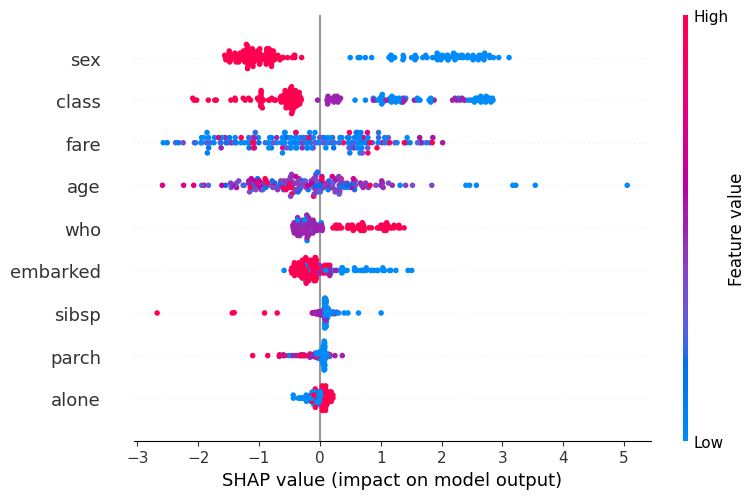

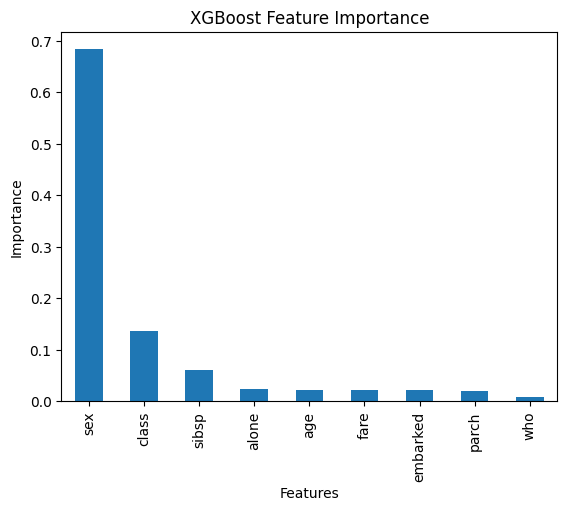

In [9]:
# 1. Import libraries

import pandas as pd
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


# 2. Load dataset

df = pd.read_csv("Titanic.csv")


# 3. Handle missing values

df["age"] = df["age"].fillna(df["age"].mean())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])


# 4. Convert categorical data into numbers

le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["embarked"] = le.fit_transform(df["embarked"])
df["class"] = le.fit_transform(df["class"])
df["who"] = le.fit_transform(df["who"])
df["alone"] = df["alone"].astype(int)


# 5. Separate input and output

X = df.drop("survived", axis=1)
y = df["survived"]


# 6. Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 7. XGBoost

xgb = XGBClassifier(random_state=42)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_accuracy)


# 8. LightGBM

lgb = LGBMClassifier(random_state=42, verbosity=-1)

lgb.fit(X_train, y_train)

lgb_pred = lgb.predict(X_test)

lgb_accuracy = accuracy_score(y_test, lgb_pred)

print("LightGBM Accuracy:", lgb_accuracy)


# 9. Compare accuracies

print("\nModel Comparison")
print("----------------")
print("XGBoost :", xgb_accuracy)
print("LightGBM:", lgb_accuracy)


# 10. SHAP explanation

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)


# 11. Feature importance

importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).plot(kind="bar")

plt.title("XGBoost Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()